In [45]:
import pandas as pd
import numpy as np
import utility.my_utils as deniz
import gc
import os
import mne


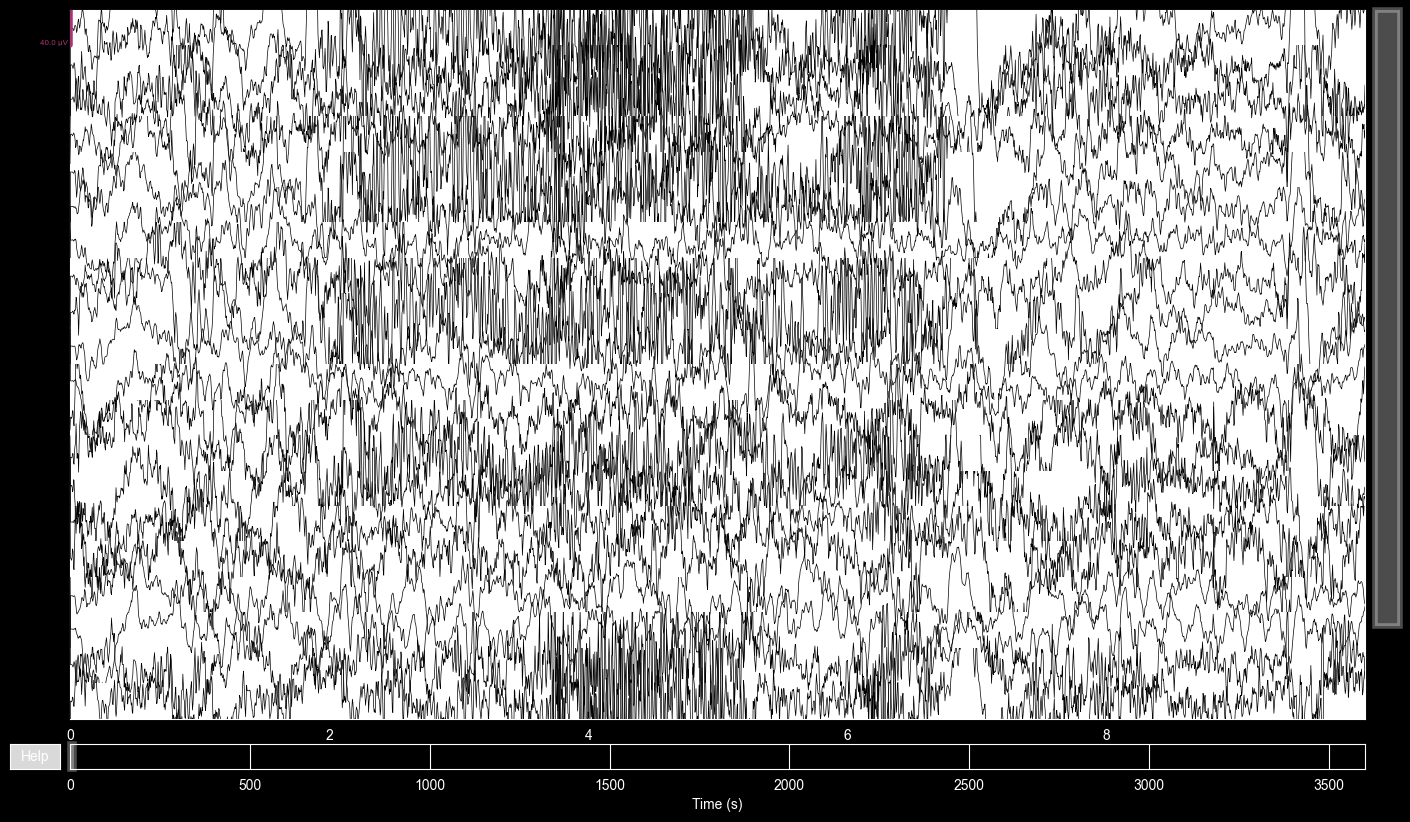

In [50]:
dataset_path = 'data-understanding/data/chb-mit'
raw_folders= deniz.get_folder_names(dataset_path)
raw_paths =deniz.get_edf_paths(dataset_path, raw_folders)
print(raw_paths[0])

raw = mne.io.read_raw_edf(raw_paths[0], preload=False, verbose=False)
raw.plot()


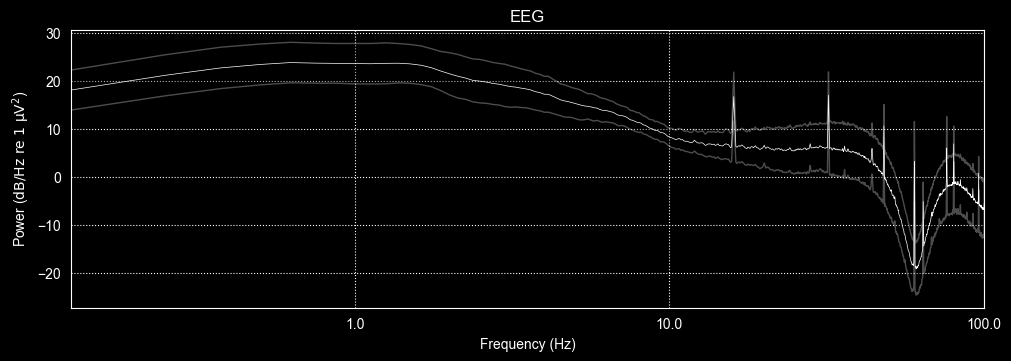

In [56]:
# 1. Compute PSD
spectrum = raw.compute_psd(fmax=100)

# Use the dark_background style context for visibility
with plt.style.context('dark_background'):

    # 2. Plot without averaging (Spatial colors)
    fig1 = spectrum.plot(
        average=False,
        picks="data",
        exclude="bads",
        amplitude=False,
        spatial_colors=True
    )
    # Force figure facecolor to match if it doesn't automatically
    fig1.patch.set_facecolor('white')

    # 3. Plot with averaging and log scale
    fig2 = spectrum.plot(
        average=True,
        xscale="log",
        amplitude=False
    )
    if hasattr(fig2.axes[0], 'get_lines'):
        for line in fig2.axes[0].get_lines():
            line.set_color('white')  # Make the main signal line white

    plt.show()

# After preprocessing

In [58]:
df = pd.read_csv('data-understanding/all_preprocess_pipeline_seizure.csv')
df[df['file'] == 'chb01_03.edf']
sample = np.load('02_epochs/chb01_03_E1498_L1.npz')
X = sample['x'] # EEG Sinyali
y = sample['y'] # 0 veya 1
X
y

array(1)

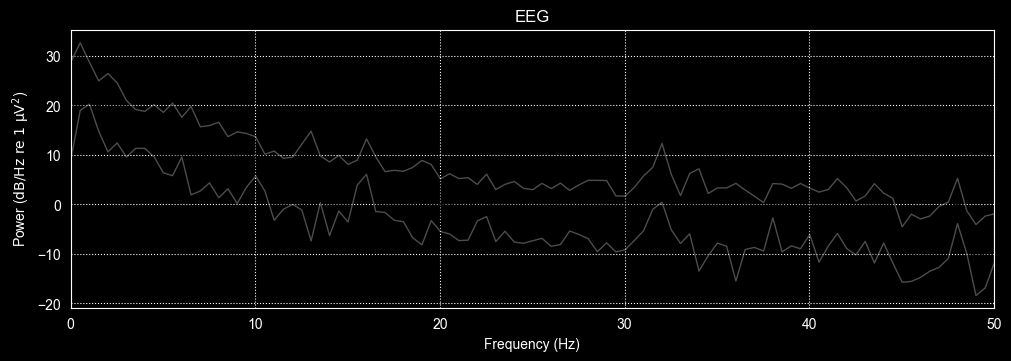

In [64]:
# Use os.path.join to handle the folder '02_epochs' correctly
file_path = os.path.join("02_epochs", "chb01_01_E000_L0.npz")

print(f"Loading file from: {file_path}")

try:
    # Load the .npz file
    preprocessed_data = np.load(file_path, allow_pickle=True)

    # 2. FIX: Extract the actual data array
    # .npz files behave like dictionaries. We need the array inside.
    # Usually it's under 'arr_0', 'X', or 'data'.
    print(f"Keys in file: {preprocessed_data.files}")
    eeg_data = preprocessed_data[preprocessed_data.files[0]]

    # 3. FIX: Define Metadata manually
    # (You cannot get 'sfreq' from the 'dataset_path' string)
    sfreq = 128.0  # Assuming 128Hz as per your previous preprocessing
    ch_names = [   # Standard CHB-MIT 18 channels
        'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
        'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
        'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
        'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
        'FZ-CZ', 'CZ-PZ'
    ]

    # 4. Handle Shape Mismatch (Transposing if needed)
    # MNE expects (Channels, Time). If data is (Time, Channels), transpose it.
    if eeg_data.shape[0] != len(ch_names):
        print(f"Transposing data. Original shape: {eeg_data.shape}")
        eeg_data = eeg_data.T

    # Create MNE info object
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')

    # Create RawArray object
    raw = mne.io.RawArray(eeg_data, info)

    # Plot raw traces
    # Using a dark background context for better visibility
    with plt.style.context('dark_background'):
        raw.plot(scalings='auto', duration=10, n_channels=len(ch_names), show=True, title="Preprocessed EEG")

        # Plot power spectral density (PSD)
        # Using compute_psd() is the modern MNE syntax
        raw.compute_psd(fmax=50).plot(average=True, spatial_colors=True)
        plt.show()

except FileNotFoundError:
    print(f" Error: Could not find file at '{file_path}'")
    print("Please check if the folder '02_epochs' exists and the filename is correct.")
except Exception as e:
    print(f" An error occurred: {e}")

In [2]:
# CELL 9: Visualize Preprocessing Effect
# ============================================

print("="*60)
print("📊 VISUALIZING PREPROCESSING EFFECT")
print("="*60)

fs=128

# Take 5 seconds of data from one channel
channel_idx = 0
duration = 5  # seconds
samples = duration * fs

raw_segment = signals[channel_idx, :samples]
clean_segment = preprocessor.preprocess(signals[:, :samples])[channel_idx]

time = np.arange(samples) / fs

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Plot 1: Raw Signal
axes[0].plot(time, raw_segment, 'b-', linewidth=0.5)
axes[0].set_title(f'1️⃣ Raw Signal (Channel: {ch_names[channel_idx]})', fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, duration)

# Plot 2: Cleaned Signal
axes[1].plot(time, clean_segment, 'g-', linewidth=0.5)
axes[1].set_title('2️⃣ After Preprocessing (Filtered + Normalized)', fontweight='bold', color='green')
axes[1].set_ylabel('Normalized')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, duration)

# Plot 3: Power Spectrum Comparison
from scipy.signal import welch

freqs_raw, psd_raw = welch(raw_segment, fs=fs, nperseg=512)
freqs_clean, psd_clean = welch(clean_segment, fs=fs, nperseg=512)

axes[2].semilogy(freqs_raw, psd_raw, 'b-', alpha=0.7, label='Raw', linewidth=1.5)
axes[2].semilogy(freqs_clean, psd_clean, 'g-', alpha=0.7, label='Cleaned', linewidth=1.5)
axes[2].axvline(x=60, color='red', linestyle='--', alpha=0.5, label='60 Hz (removed)')
axes[2].set_title('3️⃣ Power Spectrum (Frequency Content)', fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Power')
axes[2].set_xlim(0, 100)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('preprocessing_effect.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Preprocessing Effects:")
print("   ✓ High-frequency noise removed")
print("   ✓ 60 Hz power line interference filtered")
print("   ✓ Signal normalized to consistent scale")
print("   ✓ Extreme artifacts clipped")

print("\n" + "="*60)
print("✅ Preprocessing visualization complete!")
print("="*60)

NameError: name 'signals' is not defined

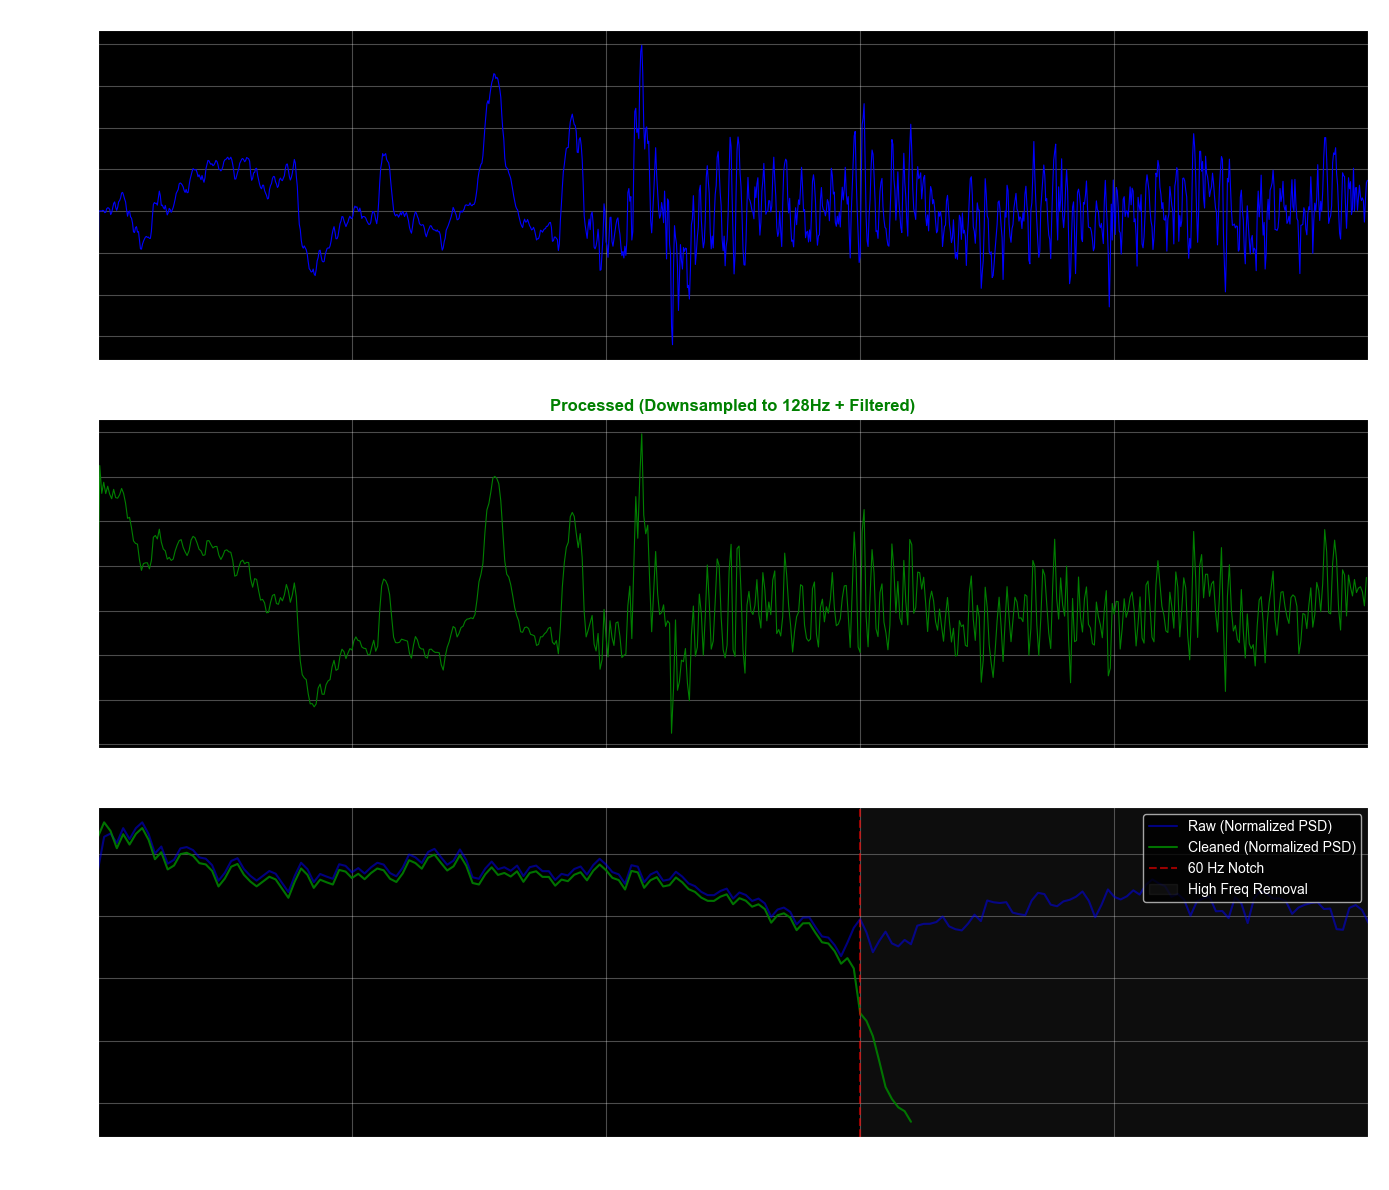

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import mne
from scipy.signal import welch
from pathlib import Path  # Added missing import
import utility.my_utils as deniz
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# ============================================
# 1. SETUP & LOADING
# ============================================
dataset_path = 'data-understanding/data/chb-mit'
subject_folders = deniz.get_folder_names(dataset_path)

FINAL_CHANNELS = [
    'FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1',
    'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1',
    'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2',
    'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2',
    'FZ-CZ', 'CZ-PZ'
]

if subject_folders:
    # Get paths for the first subject
    edf_paths = deniz.get_edf_paths(dataset_path, subject_folders[0])
    file_path = edf_paths[0]
    print(f"🔍 Loading data from: {file_path}")

    # 1. Load using your utility
    raw = deniz.fix_eeg_channels(file_path, FINAL_CHANNELS)

    # 2. Extract info before processing
    original_fs = int(raw.info['sfreq'])
    print(f"   Original Sampling Rate: {original_fs} Hz")

    # Select a specific channel to visualize
    channel_name = FINAL_CHANNELS[0]
    channel_idx = raw.ch_names.index(channel_name)

    # Get 5 seconds of RAW data (converted to µV for readability)
    duration_sec = 5
    raw_samples = int(duration_sec * original_fs)
    raw_signal = raw.get_data(picks=[channel_idx], stop=raw_samples)[0] * 1e6

else:
    raise FileNotFoundError(f"No subject folders found in {dataset_path}")

# ============================================
# 2. DEFINE PREPROCESSING LOGIC
# ============================================

def get_processed_segment(raw_obj, channel_idx, duration_sec):
    # Create a copy to avoid modifying the original 'raw' object
    raw_copy = raw_obj.copy()

    # 1. Downsample
    raw_copy = deniz.downsample(raw_copy)
    new_fs = int(raw_copy.info['sfreq'])

    # 2. Apply Filtering (Bandpass + Notch)
    raw_copy = deniz.apply_filtering(raw_copy)

    # 3. Extract Data
    n_samples = int(duration_sec * new_fs)
    data = raw_copy.get_data(picks=[channel_idx], stop=n_samples)[0]

    return data, new_fs

# Get the processed version
clean_signal, new_fs = get_processed_segment(raw, channel_idx, duration_sec)

# ============================================
# 3. VISUALIZATION
# ============================================

print("="*60)
print("📊 VISUALIZING PREPROCESSING EFFECT")
print("="*60)

# Time vectors
time_raw = np.arange(len(raw_signal)) / original_fs
time_clean = np.arange(len(clean_signal)) / new_fs

# Create figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.patch.set_facecolor('white')

# Plot 1: Raw Signal
axes[0].plot(time_raw, raw_signal, 'b-', linewidth=0.8)
axes[0].set_title(f'Raw Signal (Channel: {channel_name} @ {original_fs}Hz)', fontweight='bold')
axes[0].set_ylabel('Amplitude (μV)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(0, duration_sec)

# Plot 2: Cleaned Signal
axes[1].plot(time_clean, clean_signal, 'g-', linewidth=0.8)
axes[1].set_title(f'Processed (Downsampled to {new_fs}Hz + Filtered)', fontweight='bold', color='green')
axes[1].set_ylabel('Amplitude')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(0, duration_sec)

# Plot 3: Power Spectrum Comparison
freqs_raw, psd_raw = welch(raw_signal, fs=original_fs, nperseg=original_fs*2)
freqs_clean, psd_clean = welch(clean_signal, fs=new_fs, nperseg=new_fs*2)

# Normalize PSD for visual comparison
psd_raw_norm = psd_raw / np.max(psd_raw)
psd_clean_norm = psd_clean / np.max(psd_clean)

axes[2].semilogy(freqs_raw, psd_raw_norm, 'b-', alpha=0.5, label='Raw (Normalized PSD)', linewidth=1.5)
axes[2].semilogy(freqs_clean, psd_clean_norm, 'g-', alpha=0.9, label='Cleaned (Normalized PSD)', linewidth=1.5)

# Markers
axes[2].axvline(x=60, color='red', linestyle='--', alpha=0.6, label='60 Hz Notch')
axes[2].axvspan(60, 128, color='gray', alpha=0.1, label='High Freq Removal')

axes[2].set_title('3 Power Spectrum (Frequency Content)', fontweight='bold')
axes[2].set_xlabel('Frequency (Hz)')
axes[2].set_ylabel('Normalized Power (Log Scale)')
axes[2].set_xlim(0, 100)
axes[2].legend(loc='upper right')
axes[2].grid(True, alpha=0.3, which='both')

plt.tight_layout()

# --- FIX: Ensure directory exists and separate commands ---
output_dir = Path("visualizations")
output_file = output_dir / "preprocessing_comparison.png"

plt.savefig(output_file, dpi=150, bbox_inches='tight')
plt.show()  # FIX: Moved to a new line

print("\n📋 Preprocessing Effects Observed:")
print(f"   ✓ Sampling Rate: {original_fs}Hz -> {new_fs}Hz")
print("   ✓ High-frequency noise (>60Hz) reduced")
print("   ✓ 60 Hz power line peak removed")

print("\n" + "="*60)
print("✅ Visualization complete!")
print("="*60)